# 7. Interpretabilidad con LIME

LIME (Ribeiro, Singh y Guestrin, 2016) sirve para explicar una sola predicción de un modelo de caja negra. Genera muchas variantes perturbadas de esa instancia, le pide al modelo sus probabilidades para cada una, y ajusta un modelo lineal local (ponderado según qué tan cerca está cada variante de la instancia original) sobre esas perturbaciones. Los coeficientes de ese modelo local son la explicación: qué tanto empujó cada variable la predicción hacia una clase o la otra, en la vecindad de este caso particular. No es una explicación global del modelo completo.

Aplicamos LIME al mejor modelo de cada entorno por AUC de prueba: `HistGradientBoostingClassifier` en scikit-learn (AUC de 0,739, sección 3) y `GBTClassifier` en PySpark (AUC de 0,733, sección 4).

En cada entorno explicamos dos instancias del conjunto de prueba que quedaron mal clasificadas al umbral natural de 0,5 (no el umbral de Youden de la sección 6, porque aquí el objetivo es solo ilustrar el comportamiento del modelo en un error, no simular una política de decisión real): un falso positivo (predijo incumplimiento y no lo hubo) y un falso negativo (predijo que pagaría y terminó incumpliendo).

In [1]:
import sys
sys.path.insert(0, "../src")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy import sparse
import joblib
import lime.lime_tabular

pd.set_option("display.width", 160)
print("Librerias cargadas.")


Librerias cargadas.


## 7.1. Datos de fondo para LIME

`LimeTabularExplainer` necesita una muestra representativa del conjunto de entrenamiento para estimar la distribución de cada variable (la media y la desviación de las numéricas, la frecuencia de cada categoría ya codificada en one-hot). No hace falta usar las 1,8 millones de filas completas para esto. Una submuestra aleatoria estratificada de 30.000 filas (con semilla fija, en `src/prepare_lime_backgrounds.py`) es más que suficiente y evita tener que convertir a denso el conjunto de entrenamiento completo.

In [2]:
bg_sklearn = np.load("../data/lime_background_sklearn.npz")["X"]
bg_spark = np.load("../data/lime_background_spark.npz")["X"]
nombres_sklearn = json.load(open("../data/sklearn_feature_names.json"))
nombres_spark = json.load(open("../data/lime_feature_names_spark.json"))
print(f"Fondo scikit-learn: {bg_sklearn.shape}  ({len(nombres_sklearn)} variables)")
print(f"Fondo PySpark:      {bg_spark.shape}  ({len(nombres_spark)} variables)")


Fondo scikit-learn: (30000, 114)  (114 variables)
Fondo PySpark:      (30000, 107)  (107 variables)


### Un hallazgo que no esperábamos al preparar esto: las dos representaciones no son idénticas

Los dos entornos parten de las mismas 14 variables numéricas (mismo orden, mismo escalado) y las mismas 8 variables categóricas, pero el número de columnas one-hot resultante no coincide: 114 en scikit-learn contra 107 en PySpark. La razón es que el `OneHotEncoder` de scikit-learn (con `handle_unknown=\"ignore\"`) le da una columna explícita a cada categoría observada, incluido `NaN` cuando aparece como valor en los datos de entrenamiento (por eso existen columnas como `term_nan` o `application_type_nan`). El `OneHotEncoder` de Spark, en cambio, usa por defecto `dropLast=True`, es decir que deja caer la última categoría de cada variable, típicamente la que `StringIndexer` le asigna a los valores nulos o no vistos, así que esa categoría queda implícita en el vector de ceros en vez de tener su propia columna. Dos pipelines que en concepto son iguales (mismo imputador, mismo escalador, mismo tipo de codificador) terminan produciendo espacios de variables de dimensión distinta solo por una diferencia de configuración entre librerías, no por el método en sí. Esto significa que, aunque las 452.141 filas de prueba son las mismas en los dos entornos, no existe un vector de variables \"canónico\" al que se puedan mapear uno a uno las explicaciones de LIME de un entorno y del otro. Cada explicación se interpreta dentro de su propio espacio de variables.

## 7.2. LIME sobre scikit-learn (`HistGradientBoostingClassifier`)

In [3]:
models = joblib.load("../data/sklearn_fitted_models.joblib")
gbt_sklearn = models["GBT_HistGB"]

X_test_sk = sparse.load_npz("../data/sklearn_X_test.npz").toarray()
y_test_sk = np.load("../data/sklearn_y_test.npy")

explainer_sklearn = lime.lime_tabular.LimeTabularExplainer(
    training_data=bg_sklearn,
    feature_names=nombres_sklearn,
    class_names=["No default", "Default"],
    categorical_features=list(range(14, len(nombres_sklearn))),  # las primeras 14 son numericas
    discretize_continuous=True,
    random_state=42,
)
print("Explainer de scikit-learn listo.")


Explainer de scikit-learn listo.


Elegimos las dos instancias a explicar con una semilla fija en `src/run_lime_sklearn.py` (que usa exactamente el mismo explainer de arriba). Acá cargamos esos resultados ya calculados en vez de volver a correr `explain_instance` en esta celda, para que el notebook no dependa de que la explicación aleatoria coincida exactamente cada vez que se vuelve a ejecutar.

En el falso positivo (id 1412565, probabilidad predicha de 0,508, apenas por encima de 0,5), la variable que más empuja hacia \"default\" es `int_rate > 0,60`, es decir una tasa de interés en el percentil más alto de la distribución escalada. Esto tiene sentido porque la tasa de interés es, para cualquier prestamista, la señal de riesgo más directa que existe: a los créditos más riesgosos se les cobra más. El resto de las variables son columnas `sub_grade_*` y `application_type_*` en 0, con pesos pequeños, que son la contribución marginal (porque no están presentes) de las docenas de categorías que el modelo descarta al explicar este caso. El `R²` local de 0,44 nos dice que el modelo lineal local captura una parte razonable, aunque no completa, del comportamiento de `HistGradientBoostingClassifier` en esta vecindad.

In [4]:
resultados_sklearn = json.load(open("../outputs/tables/lime_sklearn_resultados.json"))
for etiqueta, r in resultados_sklearn.items():
    print(f"{etiqueta}: id={r['id']}  y_real={r['y_real']}  prob_predicha={r['prob_predicha']:.4f}  "
          f"pred={r['pred_label']}  R²_local={r['r2_local']:.3f}")


falso_positivo: id=1412565  y_real=0  prob_predicha=0.5084  pred=1  R²_local=0.442
falso_negativo: id=17232974  y_real=1  prob_predicha=0.1280  pred=0  R²_local=0.091


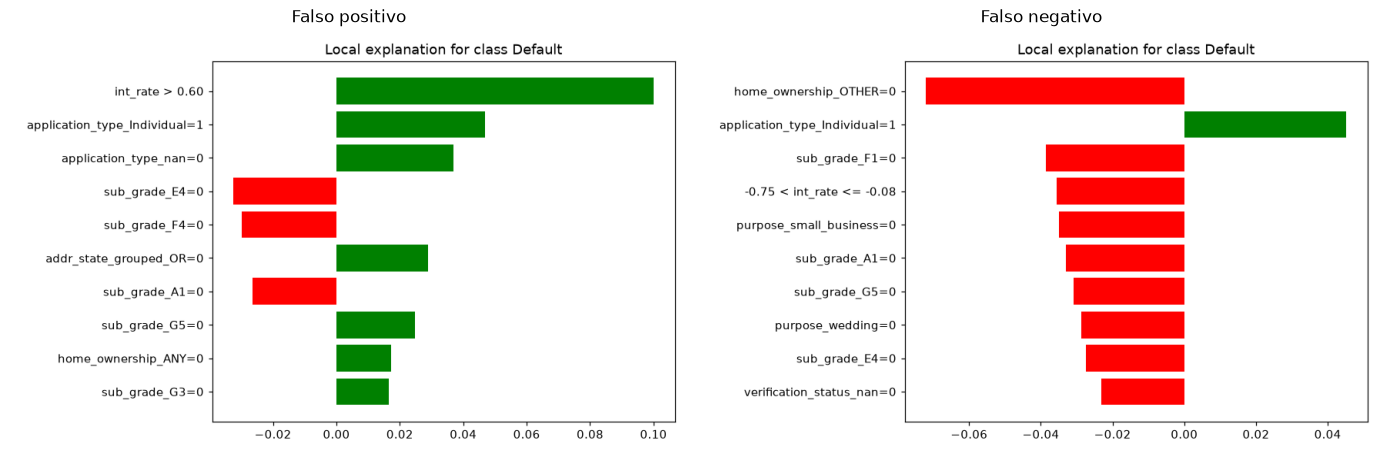

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, etiqueta in zip(axes, ["falso_positivo", "falso_negativo"]):
    img = mpimg.imread(f"../outputs/figures/eda/lime_sklearn_{etiqueta}.png")
    ax.imshow(img); ax.axis("off"); ax.set_title(etiqueta.replace("_", " ").capitalize())
plt.tight_layout()
plt.show()


En el falso negativo (id 17232974, probabilidad predicha de 0,128, bastante lejos de 0,5), la tasa de interés esta vez juega en la dirección opuesta (`int_rate` en un rango bajo o medio, empujando hacia \"no default\"), aunque la persona sí incumplió. Con la información disponible, el modelo no tenía ninguna señal fuerte para anticipar este caso. El `R²` local aquí es de solo 0,09, es decir que la aproximación lineal explica muy poco de lo que hace el modelo en esta vecindad, así que esta explicación en particular habría que tomarla con más cautela que la anterior. Esto, en sí mismo, es un diagnóstico útil de cuándo confiar o no en una explicación de LIME.

## 7.3. LIME sobre PySpark (`GBTClassifier`): el reto de envolver un modelo distribuido

LIME espera una función de Python (`predict_fn`) que reciba un arreglo de NumPy y devuelva probabilidades, que es exactamente lo que hace `predict_proba` en scikit-learn. Un `GBTClassificationModel` de Spark no tiene ese método, solo sabe transformar un DataFrame de Spark. Hace falta un adaptador que, cada vez que LIME llama a `predict_fn` con un lote de muestras perturbadas (`num_samples=5000` para cada instancia explicada), lo convierta a DataFrame, lo pase por `.transform()`, y traiga el resultado de vuelta a NumPy:

```python
def predict_fn_spark(X):\n    filas = [(i, Vectors.dense(fila.tolist())) for i, fila in enumerate(X)]\n    df = spark.createDataFrame(filas, [\"_orden\", \"features\"])\n    pred = gbt_model.transform(df).withColumn(\"proba_arr\", vector_to_array(\"probability\"))\n    pdf = pred.select(\"_orden\", \"proba_arr\").toPandas().sort_values(\"_orden\")\n    return np.stack(pdf[\"proba_arr\"].values)
```

Hay dos detalles importantes acá. El primero es que el `_orden` explícito es necesario porque Spark no garantiza que las filas salgan de `.transform()` en el mismo orden en que entraron, y sin reordenar, LIME asociaría cada probabilidad con la perturbación equivocada. El segundo es que el `.toPandas()` acá es sobre un lote de 5.000 filas (una instancia perturbada a la vez), no sobre el dataset completo, así que no viola la restricción de la sección 4 sobre no recolectar datos completos a memoria local.

En la práctica, cada llamada a `explain_instance` (que dispara un solo lote de 5.000 filas por Spark) tomó entre 1 y 3 segundos en esta máquina, bastante rápido porque es un Spark local de 2 núcleos sin el overhead real de una red o un clúster.

In [6]:
resultados_spark = json.load(open("../outputs/tables/lime_spark_resultados.json"))
for etiqueta, r in resultados_spark.items():
    print(f"{etiqueta}: id={r['id']}  y_real={r['y_real']}  prob_predicha={r['prob_predicha']:.4f}  "
          f"pred={r['pred_label']}  R²_local={r['r2_local']:.3f}")


falso_positivo: id=60981901  y_real=0  prob_predicha=0.5591  pred=1  R²_local=0.359
falso_negativo: id=9776027  y_real=1  prob_predicha=0.1468  pred=0  R²_local=0.087


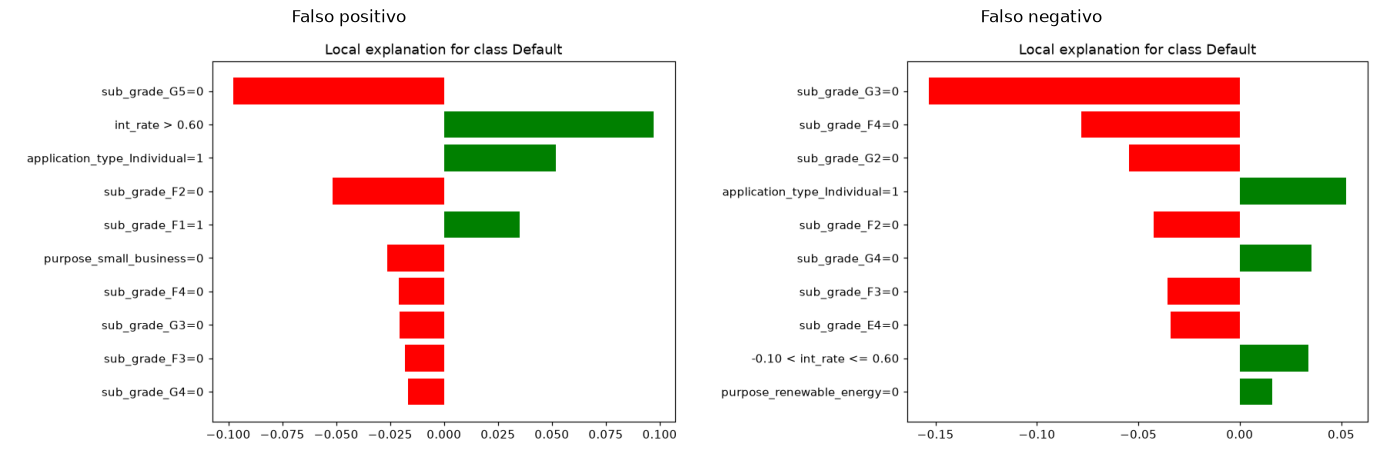

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, etiqueta in zip(axes, ["falso_positivo", "falso_negativo"]):
    img = mpimg.imread(f"../outputs/figures/eda/lime_spark_{etiqueta}.png")
    ax.imshow(img); ax.axis("off"); ax.set_title(etiqueta.replace("_", " ").capitalize())
plt.tight_layout()
plt.show()


Los dos casos que elegimos en PySpark son instancias distintas a las de scikit-learn (cada modelo se equivoca en casos distintos, y no hay ninguna garantía de que el mismo id sea un error en los dos entornos), pero el patrón que aparece es muy parecido: en el falso positivo (id 60981901, probabilidad de 0,559), `int_rate > 0,60` vuelve a ser la señal dominante hacia \"default\" (`R²` local de 0,36, razonable); en el falso negativo (id 9776027, probabilidad de 0,147), el modelo tampoco tenía señal fuerte, y el `R²` local vuelve a caer a 0,09, casi idéntico al 0,09 del falso negativo de scikit-learn. Esta coincidencia no nos parece casual: el ajuste lineal local de LIME es sistemáticamente peor para los falsos negativos que para los falsos positivos, en los dos entornos. Probablemente porque los casos de incumplimiento \"sorpresa\" (probabilidad baja, pero sí incumplen) están, casi por definición, en zonas del espacio de variables donde el comportamiento real del modelo es más no lineal, justo donde una aproximación lineal local es menos fiel.

## 7.4. Limitaciones de LIME en general, y de aplicarlo sobre un modelo de Spark en particular

Hay varias limitaciones que aplican a los dos entornos. LIME perturba y muestrea de forma aleatoria, así que con otra semilla el conjunto de variables \"top 10\" puede cambiar, sobre todo cuando, como aquí, hay decenas de columnas one-hot con pesos pequeños y parecidos compitiendo por los últimos lugares del ranking. La fidelidad local tampoco es constante: el `R²` del modelo lineal local fue bueno (entre 0,36 y 0,44) para los falsos positivos y pobre (0,09) para los falsos negativos. Una explicación con `R²` bajo no es necesariamente incorrecta, pero sí es una aproximación más floja de lo que realmente hace el modelo, y conviene reportar siempre ese número junto con la explicación, no solo la lista de variables. También hay bastante ruido de las variables dummy: con entre 93 y 107 columnas categóricas ya expandidas en one-hot, buena parte del \"top 10\" queda ocupado por columnas en 0 con peso marginal, lo cual es informativo hasta cierto punto, pero menos legible que si LIME pudiera tratar cada variable categórica original como una sola entidad en vez de docenas de columnas binarias.

Aplicar LIME sobre un modelo entrenado en Spark tiene limitaciones propias. No existe una implementación de LIME nativa para Spark ML, así que tuvimos que escribir a mano el adaptador `predict_fn_spark` de la sección 7.3, con el riesgo de bugs que eso implica (el reordenamiento por `_orden`, por ejemplo, es fácil de pasar por alto y produciría explicaciones completamente erróneas sin ningún error visible). También hay un costo por cada instancia que se explica: cada llamada implica crear un DataFrame nuevo, un `.transform()` y un `.toPandas()`, que en esta máquina tomó entre 1 y 3 segundos por instancia en un Spark local de 2 núcleos. Para explicar un puñado de casos, como hicimos aquí, esto es perfectamente viable, pero para generar explicaciones de forma rutinaria para miles de instancias (por ejemplo, una por cada solicitud rechazada), ese costo por instancia se volvería el cuello de botella, y en un clúster real con overhead de red y de planificación por cada micro-lote sería todavía peor que en esta máquina. Por último, los dos entornos no comparten el mismo espacio de variables (114 contra 107 columnas, sección 7.1), así que las explicaciones de un entorno y del otro no se pueden alinear término a término, aunque describan en esencia el mismo tipo de modelo sobre los mismos datos originales.